# Method to cluster the points

DBSCAN (Density-Based Spatial Clustering) is good for data which contains clusters of similar density and can find clusters of arbitrary shape. It also doesn't not require specifying the number of clustering in advance, which suits the case study very well.

Before performing DBSCAN, we could use PCA to rotate the point cloud into axes that better match the wire geometry, making it easier to distinguish the high-variance along-wire direction from the lower-variance directions that actually separate one wire from another.

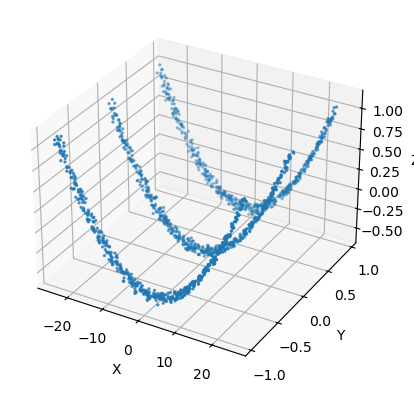

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from research import read_dataset, DIFFICULTIES

# Start from the easy case
data = read_dataset(DIFFICULTIES[0])

pca_result = PCA(n_components=3).fit_transform(data)

data["pc1"] = pca_result[:,0]
data["pc2"] = pca_result[:,1]
data["pc3"] = pca_result[:,2]

ax = plt.figure().add_subplot(projection="3d")
ax.scatter(data["pc1"], data["pc2"], data["pc3"], s = 2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()



Next step we tried to use DBSCAN to cluster the points. pc1 means the direction along the wire, which matter less to the clustering process, so we give it a lower weight.

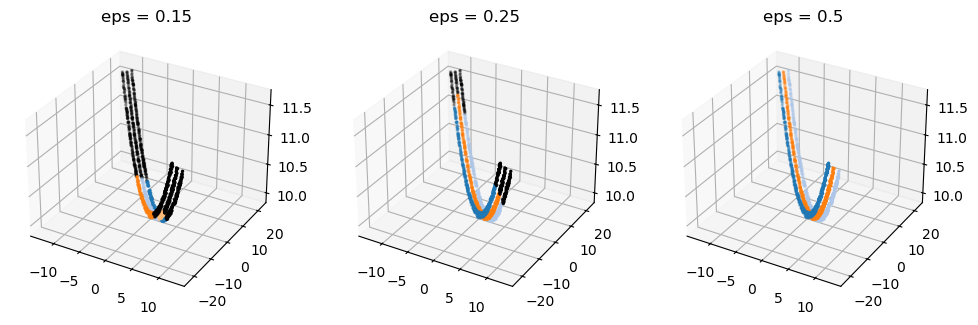

In [2]:
from research import get_color

X_cluster = np.column_stack([
    0.05 * data["pc1"],
    data["pc2"],
    data["pc3"],
])

fig = plt.figure(figsize=(12,4))
for i, eps in enumerate([0.15, 0.25, 0.5]):
    clustering = DBSCAN(eps = eps, min_samples = 50).fit(X_cluster)
    data["label"] = clustering.labels_

    colors = np.array([get_color(label) for label in data["label"]])

    ax = fig.add_subplot(1,3,i+1,projection="3d")
    ax.scatter(data["x"], data["y"], data["z"], c = colors, s = 2)
    ax.set_title(f"eps = {eps}")

plt.show()

However, we observed that the value of `eps`, the maximum distance between two samples for one to be considered as in the neighborhood of the other, affects the result significantly. It's not ideal that we need to manually configure the hyperparameter. Thus, HDBSCAN is a better choice since it performs DBSCAN over varying epsilon values and integrates the result to find a clustering that gives the best stability over epsilon.

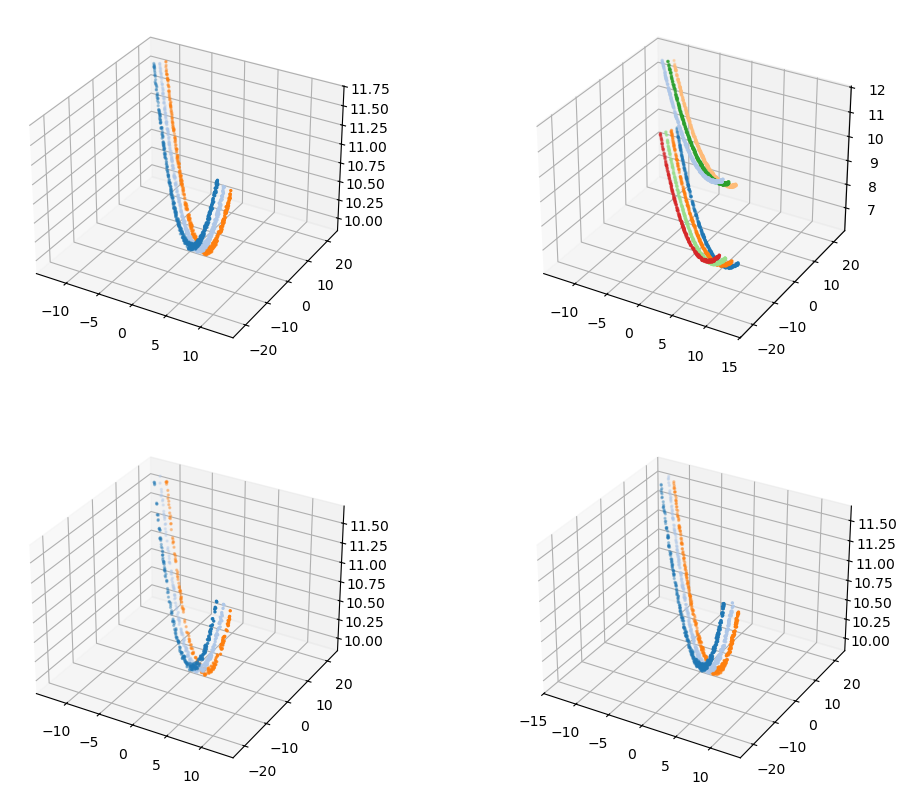

In [3]:
from sklearn.cluster import HDBSCAN

def cluster_hdbscan(data: pd.DataFrame):
    pca_result = PCA(n_components=3).fit_transform(data)

    data["pc1"] = pca_result[:,0]
    data["pc2"] = pca_result[:,1]
    data["pc3"] = pca_result[:,2]

    X_cluster = np.column_stack([
        0.05 * data["pc1"],
        data["pc2"],
        data["pc3"],
    ])
    
    clustering = HDBSCAN(copy=True, min_cluster_size=20).fit(X_cluster)
    return clustering.labels_

fig = plt.figure(figsize=(12,10))

for i, difficulty in enumerate(DIFFICULTIES):
    data = read_dataset(difficulty)
    
    labels = cluster_hdbscan(data)

    colors = np.array([get_color(label) for label in labels])

    ax = fig.add_subplot(2,2,i+1,projection="3d")
    ax.scatter(data["x"], data["y"], data["z"], c = colors, s = 2)

plt.show()

From the results we can see the HDBSCAN works well for all the cases.